In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive/melbourne_csv/

/content/drive/MyDrive/melbourne_csv


In [4]:
melb = pd.read_csv("Melbourne01.csv",low_memory=False,on_bad_lines="skip")

## Data Cleaning

In [5]:
melb.columns

Index(['2011', ' 1', ' 1.1', ' 0', ' 4', ' 24.8', ' 0.0', ' 14.0', ' 51',
       ' SE', ' 11', ' 13', ' 1007.4', ' 0.0.1'],
      dtype='object')

In [6]:
melb.columns = ['Year', 'Month', 'Day', 'Hour', 'Min', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)'] # Fixes messy / unnamed columns

In [7]:
melb.drop_duplicates().reset_index(drop=True) # Removes repeated rows

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575950,2025,03,12.0,15.0,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0
575951,2025,03,12.0,15.0,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0
575952,2025,03,12.0,16.0,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0
575953,2025,03,12.0,16.0,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0


In [8]:
melb_str = melb[melb["Month"].map(type) == str]

In [9]:
melb_str["Month"].unique()

array([' 1', ' 2', ' 3', ' 4', ' 5', ' 6', ' 7', ' 8', ' 9', ' 10', ' 11',
       ' 12', ' 1\t18\t11\t00\t18.8\t15.9\t9.6\t55\tS\t32\t43\t1014.8\t0',
       ' 1\t18\t11\t30\t20\t16.8\t10.1\t53\tS\t28\t43\t1015.1\t0',
       ' 1\t18\t12\t00\t19\t14.8\t11.1\t60\tS\t32\t43\t1015.4\t0',
       ' 1\t18\t12\t30\t19.2\t14.9\t9.4\t53\tSSE\t35\t48\t1015.6\t0',
       ' 1\t18\t13\t00\t19.4\t15.9\t8.7\t50\tS\t30\t44\t1015.9\t0',
       ' 1\t18\t13\t30\t19.5\t15.9\t8.5\t49\tS\t33\t50\t1016.2\t0',
       ' 1\t18\t14\t00\t19.3\t15.3\t8.3\t49\tSSE\t33\t46\t1016\t0',
       ' 1\t18\t14\t30\t19.3\t15.8\t8.9\t51\tS\t33\t50\t1015.9\t0',
       ' 1\t18\t15\t00\t19.4\t15.3\t8.7\t50\tS\t35\t48\t1015.6\t0',
       ' 1\t18\t15\t30\t19.2\t14.7\t7\t45\tS\t32\t46\t1015.6\t0',
       ' 1\t18\t16\t00\t19.3\t15.8\t7.1\t45\tS\t35\t50\t1015.8\t0',
       ' 1\t18\t16\t30\t19.5\t16.3\t10\t54\tS\t32\t48\t1015.8\t0',
       ' 1\t18\t17\t00\t19\t15\t8.9\t52\tSSE\t33\t41\t1015.8\t0',
       ' 1\t18\t17\t30\t18.6\t14.6\t8.3

In [10]:
tabbed_months = melb_str["Month"].unique()[12:28]

In [11]:
n_position = 580364
for month in tabbed_months:
    month = month.split("\t")
    empty_first = [""] + month
    row = pd.Series(empty_first)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row= row.to_list()
    melb.loc[n_position] = row
    melb.iloc[n_position,0] = 2017
    n_position +=1

/tmp/ipykernel_7722/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_7722/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_7722/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_7722/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a fut

In [12]:
fix_year = melb[melb['Month'].isna()].loc[::,"Year"]
indices = melb[melb['Month'].isna()].index.to_list()

In [13]:
y_position = 0
for year in fix_year:
    year = year.strip()
    year = year.split("\t")
    # row = pd.to_numeric(pd.Series(year), errors = 'ignore').to_list()

    row = pd.Series(year)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row=row.to_list()

    y_ind = indices[y_position]
    melb.loc[y_ind] = row
    y_position +=1               # Fixes rows where: data got merged into one column and tabs (\t) broke structure (frm.. melb_str...)

In [14]:
melb[melb['Month'].isna()]  #Fixes rows where year exists but Month is missing

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)


In [15]:
melb["Day"] = melb["Day"].astype(int) # Converts strings to numbers

In [16]:
replace_month = {' 1': 1,            # Removeing formatting inconsistencies
                 ' 2': 2,
                 ' 3': 3,
                 ' 4': 4,
                 ' 5': 5,
                 ' 6': 6,
                 ' 7': 7,
                 ' 8': 8,
                 ' 9': 9,
                 ' 10': 10,
                 ' 11': 11,
                 ' 12': 12,
                 ' 06': 6,
                 ' 03': 3,
                 ' 04': 4,
                 ' 05': 5,
                 ' 07': 7,
                 ' 08': 8,
                 ' 09': 9,
                 ' 01': 1,
                 ' 02': 2,
                 '09': 9,
                 '05': 5,
                 '02': 2,
                 '08': 8,
                 '1': 1,
                 '6': 6,
                 '8': 8,
                 '7': 7,
                 '5': 5,
                 '11':11
                }

In [17]:
melb["Month"] = melb["Month"].replace(replace_month)

/tmp/ipykernel_7722/984582946.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  melb["Month"] = melb["Month"].replace(replace_month)


In [18]:
replace_hour = {'06': 6,
                 '03': 3,
                 '04': 4,
                 '05': 5,
                 '07': 7,
                 '08': 8,
                 '09': 9,
                 '01': 1,
                 '02': 2,
                '00': 0
                }

In [19]:
melb["Hour"] = melb["Hour"].replace(replace_hour)
melb["Hour"] = melb["Hour"].astype(int)



In [20]:


melb['Min'] = melb['Min'].astype(int)

In [21]:
melb["Air Temp (degrees C)"] = melb["Air Temp (degrees C)"].astype(float)


In [22]:
melb["Apparent Temp (degrees C)"] = melb["Apparent Temp (degrees C)"].astype(float)


In [23]:
melb["Dew Pt Temp (degrees C)"] = melb["Dew Pt Temp (degrees C)"].astype(float)


In [24]:
melb['Humidity (%)'] = melb['Humidity (%)'].astype(int)


In [25]:
melb['Wind Gust  (km/h)'] = melb['Wind Gust  (km/h)'].astype(int)

In [26]:
melb['Wind Speed (km/h)'] = melb['Wind Speed (km/h)'].astype(int)

In [27]:
melb['MSLP (hPa)'] = melb['MSLP (hPa)'].astype(float)

In [28]:
melb['Rainfall since 9 am (mm)'] = melb['Rainfall since 9 am (mm)'].str.strip()
melb['Rainfall since 9 am (mm)'] = pd.to_numeric(melb['Rainfall since 9 am (mm)'], errors = 'coerce')

In [29]:
melb = melb.rename(columns={'Min': 'Minute'})

In [30]:
melb["Datetime"] = pd.to_datetime(melb[["Year","Month", "Hour", "Day", "Minute"]], errors = 'coerce')

In [31]:
melb

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11,13,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11,11,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11,11,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11,13,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11,13,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113146,2025,3,12,15,30,33.4,32.5,14.9,32,NW,20,35,1014.6,0.0,2025-03-12 15:30:00
1113147,2025,3,12,15,34,33.5,32.9,14.5,31,NNW,26,41,1014.6,0.0,2025-03-12 15:34:00
1113148,2025,3,12,16,0,34.4,34.2,14.8,30,WNW,26,41,1014.4,0.0,2025-03-12 16:00:00
1113149,2025,3,12,16,30,33.6,32.4,14.1,30,WNW,26,41,1014.1,0.0,2025-03-12 16:30:00


In [32]:
with pd.option_context("display.max_rows",None):
    print(melb["Wind Direction"].value_counts())

Wind Direction
 N         276369
 S         136085
 W          87480
 WSW        81667
 SW         80151
 SSW        76062
 SSE        71341
 NNE        65602
 WNW        55938
 NNW        55817
 NW         40438
 SE         26632
 CALM       19598
 NE         15075
 ESE         8582
 E           7827
 ENE         7791
N             205
SW             75
S              62
SSW            60
W              43
WSW            39
WNW            30
NNE            27
NNW            20
CALM           17
NW             17
SSE            15
SE              8
 -              6
ENE             5
NE              5
 1016.6         4
 1015.9         3
E               2
ESE             2
 1015.6         2
 1017.0         2
 1017.4         2
 1014.6         2
 1019.5         2
 1021.0         2
 1020.4         2
 1016.1         2
 1019.0         1
 1026.1         1
 1025.3         1
 1014.2         1
 1015.5         1
 1026.0         1
 1024.2         1
 1008.2         1
 1003.3         1
 1029.6      

In [33]:
melb["Wind Direction"].unique()

array([' SE', ' ESE', ' NE', ' NNE', ' ENE', ' W', ' N', ' SW', ' SSE',
       ' S', ' SSW', ' WSW', ' NW', ' WNW', ' NNW', ' E', ' CALM',
       ' 1016.6', ' 1016.9', ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1',
       ' 1025.3', ' 1024.2', ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0',
       'ENE', 'NE', 'N', 'NNE', 'NNW', 'NW', 'SSW', 'SW', 'WSW', 'W',
       'WNW', ' 1015.5', 'S', 'SE', 'SSE', 'ESE', 'CALM', 'E', ' 1014.2',
       ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0', ' 1013.6',
       ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6', ' 1015.8',
       ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5', ' 1019.8',
       ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7', ' 1021.9',
       ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3', ' 1012.0',
       ' 1010.8', ' -'], dtype=object)

In [34]:
replace_direction = {' SE': 'SE',
                     ' ESE': 'ESE',
                     ' NE': 'NE',
                     ' NNE': 'NNE',
                     ' ENE': 'ENE',
                     ' W': 'W',
                     ' N': 'W',
                     ' SW': 'SW',
                     ' SSE': 'SSE',
                     ' S': 'S',
                     ' SSW': 'SSW',
                     ' WSW': 'WSW',
                     ' NW': 'NW',
                     ' WNW': 'WNW',
                     ' NNW': 'NNW',
                     ' E': 'E',
                     ' CALM': 'STILL',
                     'CALM': 'STILL',
                    ' -': "STILL"}

In [35]:
melb["Wind Direction"] = melb["Wind Direction"].replace(replace_direction)

In [36]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', 'N', ' 1015.5',
       ' 1014.2', ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0',
       ' 1013.6', ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6',
       ' 1015.8', ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5',
       ' 1019.8', ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7',
       ' 1021.9', ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3',
       ' 1012.0', ' 1010.8'], dtype=object)

In [37]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', 'N', ' 1015.5',
       ' 1014.2', ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0',
       ' 1013.6', ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6',
       ' 1015.8', ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5',
       ' 1019.8', ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7',
       ' 1021.9', ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3',
       ' 1012.0', ' 1010.8'], dtype=object)

In [38]:
# pd.set_option('display.max_rows', 20)
directions = melb["Wind Direction"].unique()

In [39]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,0.0,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,0.0,0.0,2016-02-07 09:00:00


In [40]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,0.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,0.0,0.0,2012-09-24 14:34:00


In [41]:
di_i = 0
for di in directions:

    fixed = di.strip()
    try:
        fixed = float(fixed)
    except (ValueError,TypeError):
        pass
    if isinstance(fixed,float):
        indx_list = melb.index[melb["Wind Direction"] == di].to_list()
        for i in indx_list:
            melb.loc[i,"MSLP (hPa)"] = fixed

In [42]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,1016.6,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,1016.6,0.0,2016-02-07 09:00:00


In [43]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,1017.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,1017.0,0.0,2012-09-24 14:34:00


In [44]:
for i in range(melb.shape[0]):
    if melb.loc[i, "Wind Speed (km/h)"] == 0 and melb.loc[i, "Wind Direction"] != "STILL":
        melb.loc[i, "Wind Direction"] = "STILL"

    if melb.loc[i, "Wind Direction"] == "STILL" and melb.loc[i, "Wind Speed (km/h)"] > 0.0:
        melb.loc[i, "Wind Direction"] = None

    if melb.loc[i, "Wind Speed (km/h)"] <0:
        melb.loc[i, "Wind Direction"] = None
        melb.loc[i, "Wind Speed (km/h)"] = None

    if melb.loc[i, "Wind Gust  (km/h)"] <0:
        melb.loc[i, "Wind Gust  (km/h)"] = None
        # melb.loc[i, "Wind Speed (km/h)"] = None

In [45]:
with pd.option_context('display.max_rows', None):
    print(melb["Wind Speed (km/h)"].value_counts())

Wind Speed (km/h)
13.0     93443
15.0     92110
11.0     90386
17.0     89537
9.0      83570
19.0     77005
20.0     61226
7.0      60520
22.0     54449
24.0     52009
26.0     50239
28.0     47251
30.0     39606
32.0     32826
0.0      31952
33.0     26615
35.0     21726
6.0      19908
37.0     17014
39.0     13219
41.0     10467
43.0      8221
44.0      6604
4.0       5885
46.0      5341
48.0      4428
2.0       3783
50.0      3630
52.0      2808
54.0      2171
56.0      1529
57.0      1120
59.0       752
61.0       540
63.0       381
65.0       281
67.0       181
69.0       137
70.0        76
72.0        58
74.0        41
76.0        34
80.0        20
78.0        15
83.0        10
82.0         6
85.0         6
87.0         3
89.0         2
100.0        2
1.0          1
3.0          1
Name: count, dtype: int64


In [46]:
# When there is a positive wind speed and wind direction is "STILL", I will change the wind direction to an "NaN"

# When there is a wind speed of 0, and a classified wind direction, I will change the wind direction to "STILL".

# done!

In [47]:
# melb[melb["Wind Direction"] == ' 1012.0'].index

melb.loc[657500, "Wind Direction"] = None
melb.loc[657481, "Wind Direction"] = None
melb.loc[657500, "Wind Speed (km/h)"] = None

melb.loc[657481, "Wind Speed (km/h)"] = None

In [48]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(melb.describe())

           Month        Day       Hour     Minute  Air Temp (degrees C)  \
count 1113151.00 1113151.00 1113151.00 1113151.00            1113151.00   
mean        6.45      15.76      11.44      26.12                 15.78   
min         1.00       1.00       0.00       0.00                  0.50   
25%         3.00       8.00       5.00      10.00                 11.80   
50%         6.00      16.00      11.00      30.00                 15.10   
75%         9.00      23.00      17.00      40.00                 18.90   
max        12.00      31.00      23.00      59.00                 43.50   
std         3.44       8.81       6.89      17.24                  5.62   

       Apparent Temp (degrees C)  Dew Pt Temp (degrees C)  Humidity (%)  \
count                 1113151.00               1113151.00    1113151.00   
mean                       12.05                     9.01         66.95   
min                     -9999.00                    -9.60          0.00   
25%                     

In [49]:
melb.loc[melb["MSLP (hPa)"] <0, "MSLP (hPa)"] = None # Removes impossible values

In [50]:
melb.describe()

,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
count,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113143e+06,1.113140e+06,1.113117e+06,1.112596e+06,1113151
mean,6.449869e+00,1.576466e+01,1.143807e+01,2.611543e+01,1.577788e+01,1.205041e+01,9.006135e+00,6.695214e+01,1.932511e+01,2.260400e+01,1.017328e+03,7.823287e-01,2016-12-30 11:54:40.273780480
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,-9.999000e+03,-9.600000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.881000e+02,0.000000e+00,2011-01-01 00:04:00
25%,3.000000e+00,8.000000e+00,5.000000e+00,1.000000e+01,1.180000e+01,7.600000e+00,6.000000e+00,5.500000e+01,1.100000e+01,1.300000e+01,1.012300e+03,0.000000e+00,2014-02-06 13:40:00
50%,6.000000e+00,1.600000e+01,1.100000e+01,3.000000e+01,1.510000e+01,1.170000e+01,8.500000e+00,6.800000e+01,1.700000e+01,2.000000e+01,1.017400e+03,0.000000e+00,2016-10-17 13:50:00
75%,9.000000e+00,2.300000e+01,1.700000e+01,4.000000e+01,1.890000e+01,1.650000e+01,1.160000e+01,8.000000e+01,2.600000e+01,3.000000e+01,1.022600e+03,2.000000e-01,2019-10-13 06:35:00
max,1.200000e+01,3.100000e+01,2.300000e+01,5.900000e+01,4.350000e+01,4.330000e+01,3.690000e+01,1.000000e+02,1.000000e+02,1.090000e+02,1.041900e+03,5.460000e+01,2025-03-12 16:30:00
std,3.442491e+00,8.809506e+00,6.886329e+00,1.724355e+01,5.615222e+00,1.517278e+01,4.062210e+00,1.766679e+01,1.059140e+01,1.272109e+01,7.636249e+00,2.955180e+00,NaN


## Rainfall vs Weather Conditions
### Which weather variables are strongest predictors of rainfall in Melbourne?


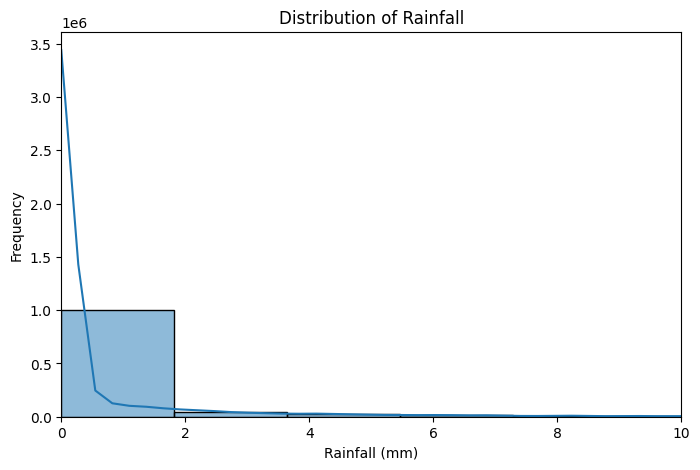

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(melb['Rainfall since 9 am (mm)'], bins=30, kde=True)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.xlim(0, 10)

plt.show()

In [52]:
# strongly right-skewed distribution,

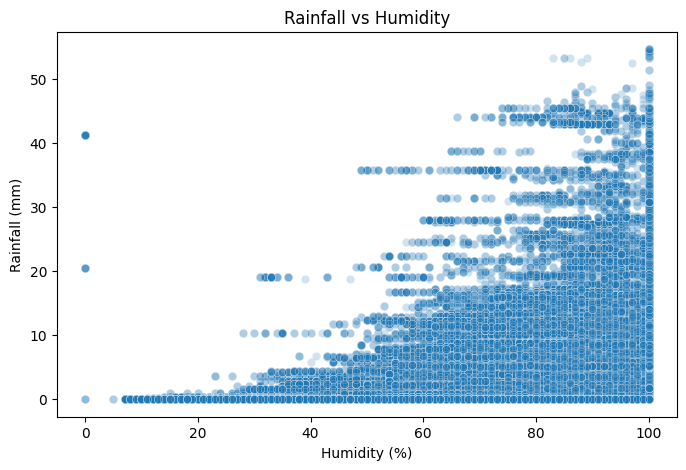

In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=melb['Humidity (%)'],
    y=melb['Rainfall since 9 am (mm)'],
    alpha=0.2
)

plt.title('Rainfall vs Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Rainfall (mm)')

plt.show()

In [56]:
# As humidity increases the rainfall tends to increase, But not strongly
# Humidity alone is not sufficient to predict rainfall,as even at high humidity the rain is not guaranteed

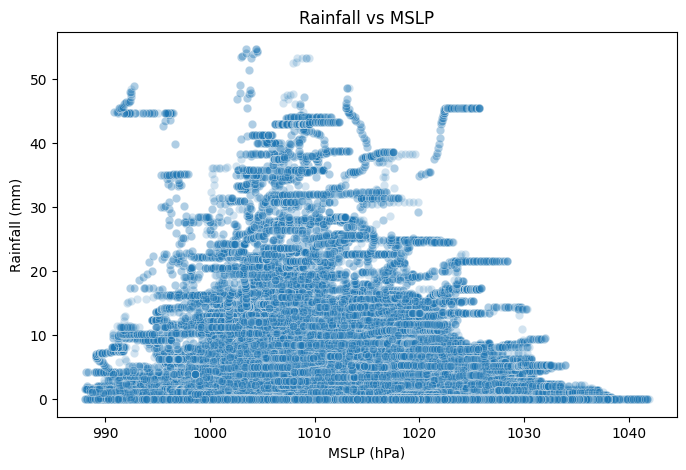

In [60]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=melb['MSLP (hPa)'], y=melb['Rainfall since 9 am (mm)'],
                alpha=0.2)

plt.title('Rainfall vs MSLP')
plt.xlabel('MSLP (hPa)')
plt.ylabel('Rainfall (mm)')

plt.show()

In [61]:
#Left side (low pressure) shows high rainfall values
#Right side (high pressure) shows low to zero rainfall
# therefore : Low pressure implies high variability + potential for heavy rain and High pressure implies stable, dry conditions
# hence MSLP is a stronger predictor of rainfall

In [64]:
melb['Rain Category'] = melb['Rainfall since 9 am (mm)'].apply(
    lambda x: 'Rain' if x > 0 else 'No Rain'
)

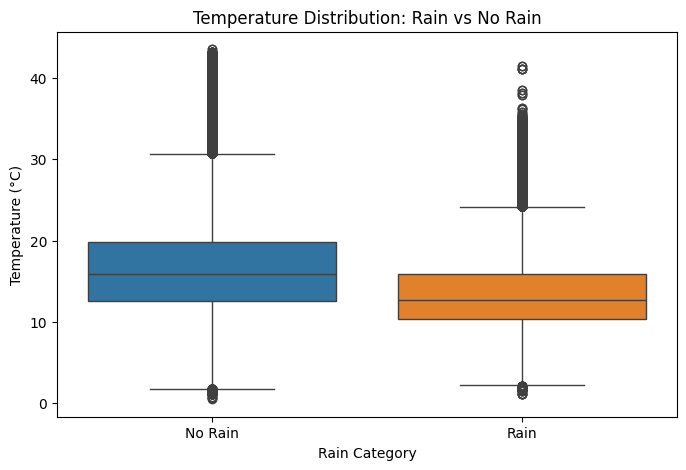

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Rain Category',
    y='Air Temp (degrees C)',
    data=melb,
    hue='Rain Category'
)

plt.title('Temperature Distribution: Rain vs No Rain')
plt.xlabel('Rain Category')
plt.ylabel('Temperature (°C)')

plt.show()

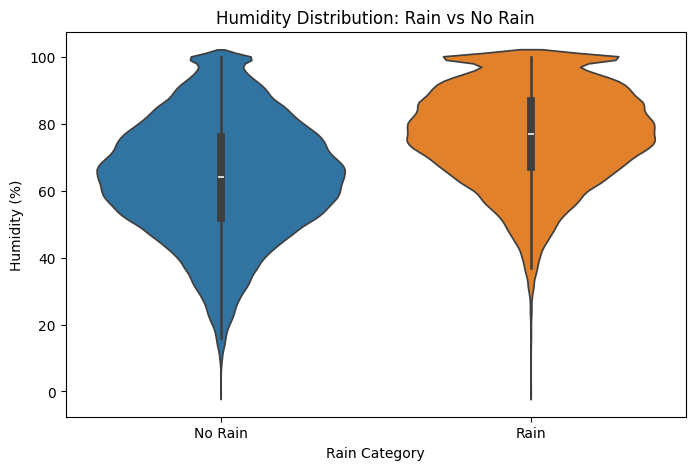

In [68]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Rain Category',
    y='Humidity (%)',
    data=melb,
    hue='Rain Category'
)

plt.title('Humidity Distribution: Rain vs No Rain')
plt.xlabel('Rain Category')
plt.ylabel('Humidity (%)')

plt.show()

In [71]:
#Rainy days are concentrated at higher humidity levels
#Non-rainy days occur across a much wider humidity range
#this confirms that humidity is necessary but not sufficient